# Polity match gaps
Shows the share of individuals with a peak-productivity window but no Cliopatria polity, per 50-year bucket.

In [1]:
import random
import tempfile
import numpy as np
import polars as pl
import duckdb
import matplotlib.pyplot as plt
from style import *

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../data/cultura/humans_clean_v2.duckdb'

BORN_AFTER_CUTOFF = 1995
BUCKET_YEARS = 50
BUCKET_MIN_INDIVIDUALS = 50
YEAR_RANGE = (-3000, 2025)

apply_style()

## Connect

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql(f"SET memory_limit='4GB'; SET threads=6; SET temp_directory='{tempfile.mkdtemp()}';")

## Load data
### Individuals

In [3]:
con.sql('''
    CREATE OR REPLACE TEMP TABLE person AS
    SELECT
        individual.entity.qid                      AS qid,
        individual.birth_date[1].year              AS birth_year,
        individual.death_date[1].year              AS death_year,
        individual_enriched.peak_productivity.start_year    AS window_start,
        COALESCE(individual_enriched.polity_count, 0) > 0   AS has_polity_match
    FROM individual
    JOIN individual_enriched
      ON individual_enriched.entity.qid = individual.entity.qid
''')

n_individuals = con.sql('SELECT COUNT(*) FROM person').fetchone()[0]
assert n_individuals == con.sql('SELECT COUNT(DISTINCT qid) FROM person').fetchone()[0]
print(f'individuals: {n_individuals:,}')
con.sql('SELECT * FROM person USING SAMPLE reservoir(5 ROWS) REPEATABLE (42)').pl()

individuals: 13,002,897


qid,birth_year,death_year,window_start,has_polity_match
str,i64,i64,i64,bool
"""Q109713340""",1929,1998,1960,true
"""Q115964931""",null,null,null,false
"""Q124047327""",1897,1985,1927,true
"""Q120267088""",null,null,null,false
"""Q109759087""",1953,null,1984,true


### Cohort (living born after 1995 excluded)

In [4]:
con.sql('''
    CREATE OR REPLACE TEMP TABLE cohort AS
    SELECT
        *,
        window_start IS NOT NULL AS has_window
    FROM person
    WHERE birth_year IS NULL
       OR birth_year <= $born_after_cutoff
       OR death_year IS NOT NULL
''', params={'born_after_cutoff': BORN_AFTER_CUTOFF})

n_cohort = con.sql('SELECT COUNT(*) FROM cohort').fetchone()[0]
print(f'before filter: {n_individuals:,}')
print(f'after filter:  {n_cohort:,}')
print(f'excluded:      {n_individuals - n_cohort:,}')

before filter: 13,002,897
after filter:  12,642,475
excluded:      360,422


### Window and polity counts per bucket

In [5]:
bucket_counts = con.sql('''
    SELECT
        CAST(FLOOR(window_start / $bucket_years) * $bucket_years AS INTEGER) AS bucket,
        COUNT(*)                                  AS individuals,
        COUNT(*) FILTER (WHERE has_polity_match)  AS with_polity
    FROM cohort
    WHERE has_window
      AND window_start BETWEEN $year_min AND $year_max
    GROUP BY bucket
    ORDER BY bucket
''', params={'bucket_years': BUCKET_YEARS, 'year_min': YEAR_RANGE[0], 'year_max': YEAR_RANGE[1]}).pl()

con.close()
print('shape:', bucket_counts.shape)
bucket_counts.head()

shape: (101, 3)


bucket,individuals,with_polity
i32,i64,i64
-3000,22,5
-2950,3,0
-2900,16,2
-2850,6,2
-2800,19,6


## Preprocessing

### Share without polity per bucket

In [6]:
last_complete_bucket = (YEAR_RANGE[1] + 1) // BUCKET_YEARS * BUCKET_YEARS - BUCKET_YEARS
print('buckets before filter:', bucket_counts.height)

share_without_polity = (
    bucket_counts
    .filter(pl.col('bucket') <= last_complete_bucket)
    .filter(pl.col('individuals') >= BUCKET_MIN_INDIVIDUALS)
    .with_columns(((1 - pl.col('with_polity') / pl.col('individuals')) * 100).alias('pct_without_polity'))
    .sort('bucket')
)
print('buckets after filter: ', share_without_polity.height)

assert share_without_polity['pct_without_polity'].is_between(0, 100).all()
share_without_polity.tail()

buckets before filter: 101
buckets after filter:  72


bucket,individuals,with_polity,pct_without_polity
i32,i64,i64,f64
1750,169191,89699,46.983587
1800,310177,181506,41.483089
1850,629177,412830,34.385713
1900,1414719,982978,30.517792
1950,2812392,1905754,32.237256


## Figures

### Share of individuals without a polity per century

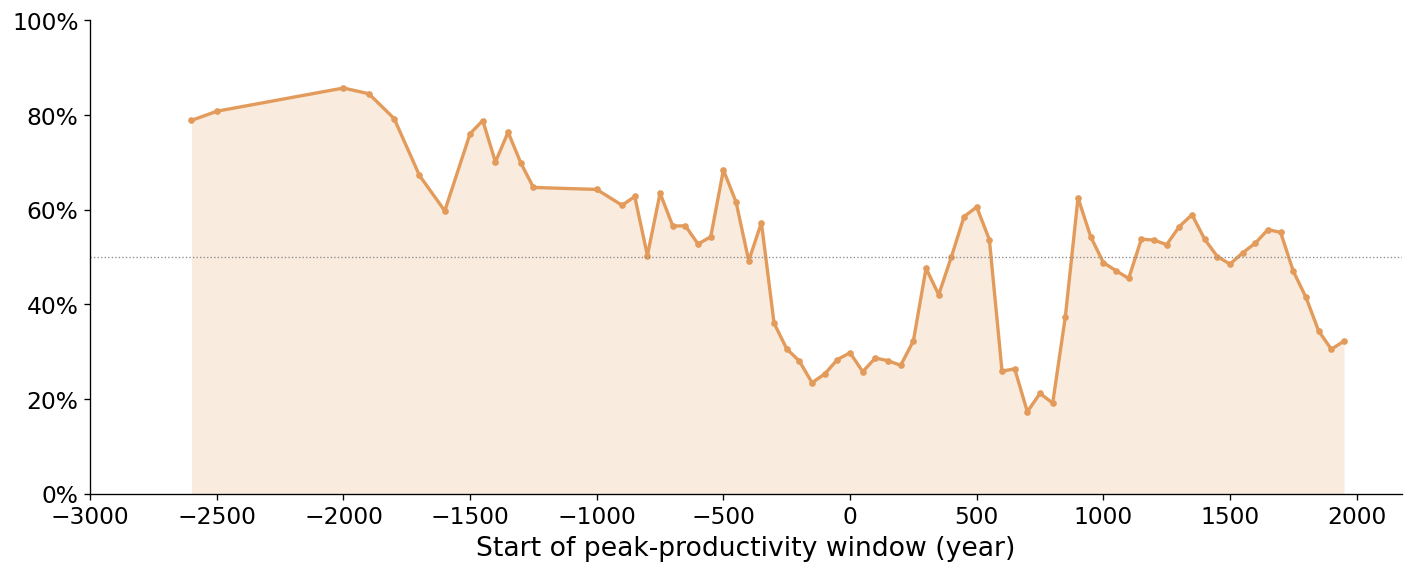

In [7]:
buckets = share_without_polity['bucket']
pct = share_without_polity['pct_without_polity']

fig, ax = plt.subplots()
ax.fill_between(buckets, 0, pct, color=POLITY_MATCH_COLORS['without_polity'], alpha=BAND_ALPHA, lw=0)
ax.plot(buckets, pct, color=POLITY_MATCH_COLORS['without_polity'], marker='o', ms=3)
ax.axhline(50, **REFERENCE_LINE)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PERCENT)
ax.set_xticks(range(YEAR_RANGE[0], 2001, 500))
ax.set_xlabel('Start of peak-productivity window (year)')
plt.tight_layout()
plt.show()